# EE 451: Communications Systems
## Lesson 11 - FM Spectrum & Binary FSK

### Learning Objectives
By the end of this lesson, you will be able to:
- Apply Bessel functions to calculate FM spectrum components
- Use Carson's rule to estimate FM bandwidth
- Explain Binary FSK as the digital counterpart to FM
- Analyze Continuous Phase FSK (CPFSK) and MSK
- Compare FM and FSK spectral characteristics

### Textbook Reference
Haykin & Moher, Chapter 4.1-4.5

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.special import jv  # Bessel function of the first kind
import warnings
warnings.filterwarnings('ignore')

# Use consistent plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete! NumPy version:", np.__version__)

Setup complete! NumPy version: 2.4.1


## Part 1: The FM Spectrum Problem and Bessel Functions

In AM, finding the spectrum is straightforward: multiplying by a carrier shifts the message spectrum to $f_c$, giving a carrier line and two sidebands. The bandwidth is simply $2f_m$.

FM is fundamentally harder. The FM signal for a single-tone message is:

$$s(t) = A_c \cos\!\left[2\pi f_c t + \beta \sin(2\pi f_m t)\right]$$

The message sits inside the argument of a cosine — a **nonlinear** operation. You cannot simply shift the message spectrum. Instead, the signal contains an infinite number of spectral lines at $f_c \pm nf_m$ for $n = 0, 1, 2, \ldots$

**Bessel functions** $J_n(\beta)$ are the mathematical tool that tells us the amplitude of each spectral line:
- Carrier at $f_c$: amplitude $A_c J_0(\beta)$
- $n$-th sideband pair at $f_c \pm n f_m$: amplitude $A_c J_n(\beta)$

This is not an approximation — it is the exact Fourier series expansion of the FM signal. The modulation index $\beta$ controls how power is distributed among the carrier and sidebands.

**Mathematical definition.** The Bessel function of the first kind of order $n$ is defined by the integral:

$$J_n(\beta) = \frac{1}{2\pi} \int_{-\pi}^{\pi} e^{j(\beta \sin\theta - n\theta)}\, d\theta$$

You do not need to evaluate this integral — in practice we use tables, plots, or `scipy.special.jv(n, beta)` in Python. The definition matters because it arises directly from expanding $e^{j\beta\sin\theta}$ (the complex FM phasor) into a Fourier series, which is how the Bessel coefficients enter the FM spectrum.

**Key properties of $J_n(\beta)$:**
- $J_0(0) = 1$, $J_n(0) = 0$ for $n > 0$ (unmodulated carrier — all power at $f_c$)
- Small $\beta$: $J_0 \approx 1$, $J_1 \approx \beta/2$, higher orders negligible (NBFM — looks like AM)
- Large $\beta$: many significant sidebands, power spreads across wide bandwidth (WBFM)
- **Power conservation:** $J_0^2(\beta) + 2\sum_{n=1}^{\infty} J_n^2(\beta) = 1$ — total power is always $A_c^2/2$ regardless of $\beta$
- Carrier null at $\beta = 2.405, 5.520, 8.654, \ldots$ — the carrier vanishes entirely and all power is in sidebands

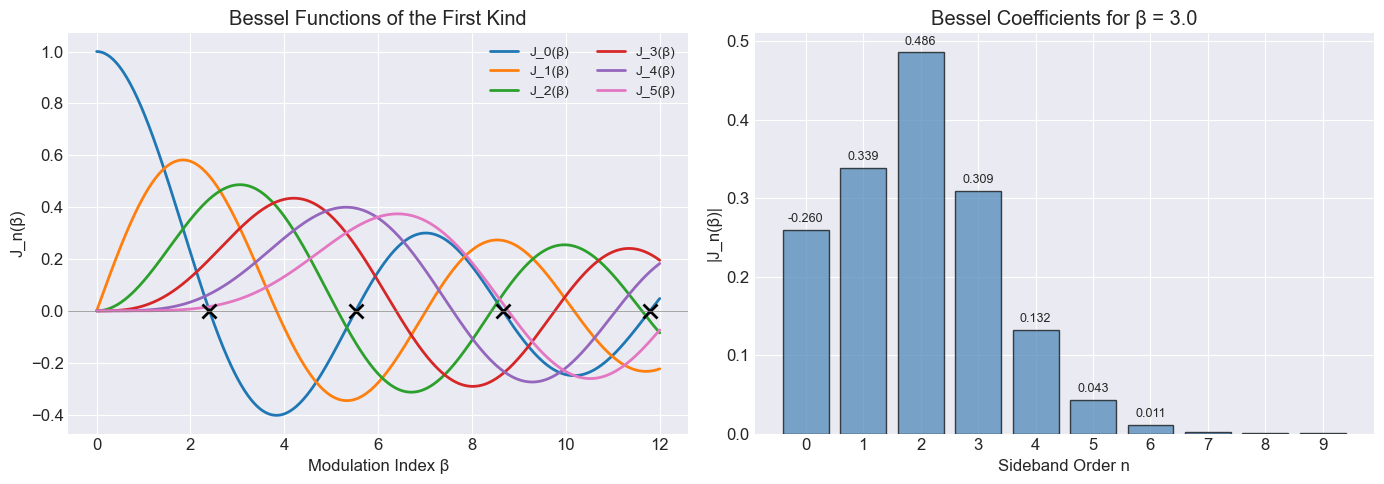

Power conservation check (beta = 3.0):
  J_0^2 + 2*sum(J_n^2, n=1..9) = 1.000000  (should be 1.0)

Bessel Function Table: J_n(beta)
 beta      J_0      J_1      J_2      J_3      J_4      J_5      J_6
-------------------------------------------------------------
 0.25    0.984    0.124    0.008    0.000    0.000    0.000    0.000
 0.50    0.938    0.242    0.031    0.003    0.000    0.000    0.000
 1.00    0.765    0.440    0.115    0.020    0.002    0.000    0.000
 2.00    0.224    0.577    0.353    0.129    0.034    0.007    0.001
 3.00   -0.260    0.339    0.486    0.309    0.132    0.043    0.011
 5.00   -0.178   -0.328    0.047    0.365    0.391    0.261    0.131
 8.00    0.172    0.235   -0.113   -0.291   -0.105    0.186    0.338

Carrier nulls (J_0 = 0): beta = 2.405, 5.520, 8.654, 11.792


In [2]:
# Part 1: Bessel Functions of the First Kind

beta_range = np.linspace(0, 12, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: J_n(beta) vs beta ---
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 0.6, 6))
for n in range(6):
    ax.plot(beta_range, jv(n, beta_range), color=colors[n], linewidth=2,
            label=f'J_{n}(\u03b2)')

# Mark carrier nulls (J_0 = 0)
nulls = [2.405, 5.520, 8.654, 11.792]
for z in nulls:
    if z < 12:
        ax.plot(z, 0, 'kx', markersize=10, markeredgewidth=2)

ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_xlabel('Modulation Index \u03b2')
ax.set_ylabel('J_n(\u03b2)')
ax.set_title('Bessel Functions of the First Kind')
ax.legend(fontsize=10, ncol=2)

# --- Plot 2: Power in components for specific beta ---
ax = axes[1]
beta_ex = 3.0
n_vals = np.arange(0, 10)
Jn_vals = jv(n_vals, beta_ex)

bars = ax.bar(n_vals, np.abs(Jn_vals), color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Sideband Order n')
ax.set_ylabel('|J_n(\u03b2)|')
ax.set_title(f'Bessel Coefficients for \u03b2 = {beta_ex}')
ax.set_xticks(n_vals)

for bar, val in zip(bars, Jn_vals):
    if abs(val) > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, abs(val) + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Verify power conservation: J_0^2 + 2*sum(J_n^2) should = 1
power_check = Jn_vals[0]**2 + 2 * np.sum(Jn_vals[1:]**2)
print(f"Power conservation check (beta = {beta_ex}):")
print(f"  J_0^2 + 2*sum(J_n^2, n=1..9) = {power_check:.6f}  (should be 1.0)")

# Print Bessel function table
print()
print("=" * 55)
print("Bessel Function Table: J_n(beta)")
print("=" * 55)
print(f"{'beta':>5}", end='')
for n in range(7):
    print(f"  {'J_'+str(n):>7}", end='')
print()
print("-" * 61)
for beta in [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]:
    print(f"{beta:>5.2f}", end='')
    for n in range(7):
        print(f"  {jv(n, beta):>7.3f}", end='')
    print()
print(f"\nCarrier nulls (J_0 = 0): beta = {', '.join(f'{z:.3f}' for z in nulls)}")

## Part 2: FM Spectrum

Single-tone FM spectrum has discrete lines at $f_c + nf_m$ for integer $n$:
- Carrier ($n = 0$) at $f_c$ with amplitude $A_c J_0(\beta)$
- $n$-th sideband pair at $f_c \pm nf_m$ with amplitude $A_c J_n(\beta)$
- Infinite sidebands in theory, but amplitude drops for large $n$

**Symmetry property:** $J_{-n}(\beta) = (-1)^n J_n(\beta)$, so odd-order sidebands have opposite signs on either side of the carrier, while even-order sidebands are symmetric. (Blue = positive, red = negative in the plots below.)

**Practical bandwidth:** Include sidebands where $|J_n(\beta)| \geq 0.01$ (1% of unmodulated carrier)

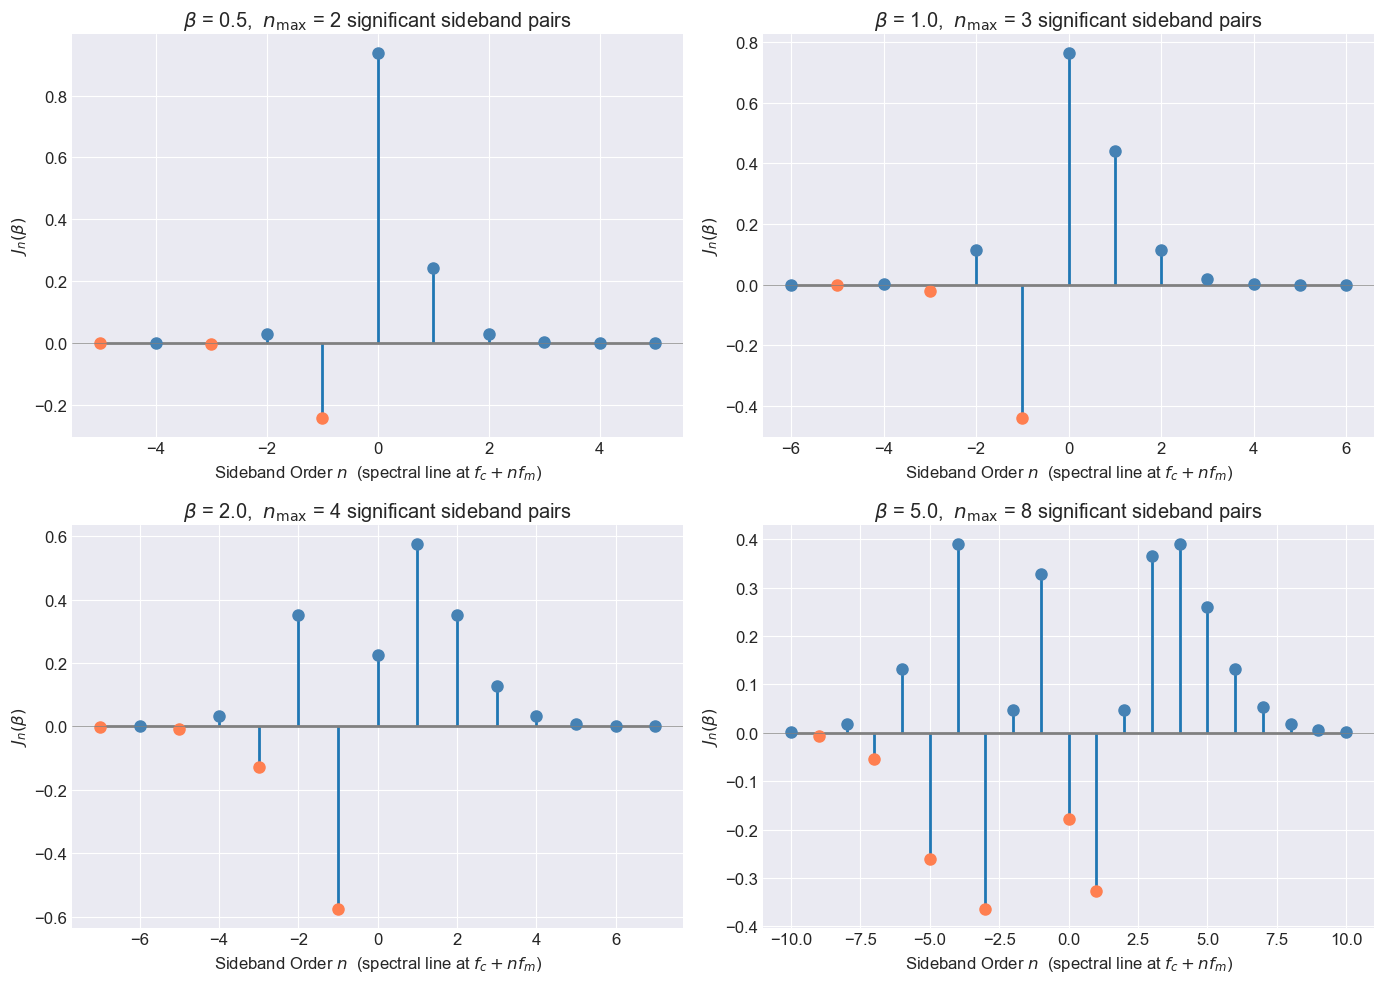

FM Spectrum: Number of Significant Sidebands
beta = 0.5: 2 significant sideband pairs
beta = 1.0: 3 significant sideband pairs
beta = 2.0: 4 significant sideband pairs
beta = 5.0: 8 significant sideband pairs


In [3]:
# Part 2: FM Spectrum at Different Modulation Indices

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
beta_values = [0.5, 1.0, 2.0, 5.0]

for idx, (beta, ax) in enumerate(zip(beta_values, axes.flatten())):
    n_max = int(beta + 5)  # Number of sidebands to show
    n_vals = np.arange(-n_max, n_max + 1)
    
    # Bessel coefficients: J_{-n}(beta) = (-1)^n * J_n(beta)
    amplitudes = [jv(n, beta) for n in n_vals]
    
    # Stem plot
    markerline, stemlines, baseline = ax.stem(n_vals, amplitudes, basefmt='gray')
    markerline.set_markersize(6)
    stemlines.set_linewidth(2)
    
    # Color code: positive = blue, negative = red
    for n, amp in zip(n_vals, amplitudes):
        color = 'steelblue' if amp >= 0 else 'coral'
        ax.plot(n, amp, 'o', color=color, markersize=8)
    
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.set_xlabel('Sideband Order $n$  (spectral line at $f_c + n f_m$)')
    ax.set_ylabel('$J_n(\\beta)$')
    
    # Count significant sidebands (1% rule)
    n_sig = 0
    for n in range(1, 20):
        if abs(jv(n, beta)) >= 0.01:
            n_sig = n
    ax.set_title(f'$\\beta$ = {beta},  $n_{{\\max}}$ = {n_sig} significant sideband pairs')

plt.tight_layout()
plt.show()

print("=" * 55)
print("FM Spectrum: Number of Significant Sidebands")
print("=" * 55)
for beta in beta_values:
    n_sig = 0
    for n in range(1, 20):
        if abs(jv(n, beta)) >= 0.01:
            n_sig = n
    print(f"beta = {beta}: {n_sig} significant sideband pairs")

## Part 3: Estimating FM Bandwidth

The Bessel expansion tells us that a single-tone FM signal has *infinitely many* sidebands. In theory, the bandwidth is infinite. In practice, most of the power is concentrated in a finite number of sidebands, so we need rules for estimating the **occupied bandwidth**.

### The 1% Sideband Rule (Exact)

Include all sidebands with amplitude $|J_n(\beta)| \geq 0.01$ (i.e., at least 1% of the unmodulated carrier). The number of significant sidebands $n_{\max}(\beta)$ depends on the modulation index:

$$BW_{1\%} = 2\, n_{\max}(\beta)\, f_m$$

where $n_{\max}(\beta)$ is the highest order $n$ for which $|J_n(\beta)| \geq 0.01$. This is precise but requires a Bessel function table for each $\beta$.

### Carson's Rule (Approximation)

A simpler estimate that captures approximately 98% of the signal power:

$$\boxed{BW_\text{Carson} \approx 2(\Delta f + f_m) = 2(\beta + 1) f_m}$$

- For large $\beta$ (WBFM): $BW \approx 2\Delta f$ — dominated by the frequency swing
- For small $\beta$ (NBFM): $BW \approx 2 f_m$ — like AM, just two sidebands
- Carson's rule smoothly interpolates between these extremes

### The Universal Curve

The **normalized bandwidth** $BW / (2f_m)$ depends only on $\beta$, not on $f_m$ or $\Delta f$ individually. Plotting this ratio vs. $\beta$ gives a **universal curve** that works for any FM signal:

$$\frac{BW}{2 f_m} = f(\beta)$$

The 1% sideband rule gives the exact curve (staircase shape, since $n_{\max}(\beta)$ is an integer). Carson's rule gives the smooth approximation $(\beta + 1)$.

### Generalization to Non-Sinusoidal Messages

For a single tone, $\beta = \Delta f / f_m$. For an **arbitrary message** $m(t)$ with bandwidth $W$, we define the **deviation ratio**:

$$D = \frac{\Delta f}{W}$$

where $\Delta f = k_f \max|m(t)|$ as before, and $W$ is the highest frequency in $m(t)$. Carson's rule generalizes to:

$$BW \approx 2(\Delta f + W) = 2(D + 1) W$$

$D$ plays the same role as $\beta$ — it determines whether the signal is narrowband ($D \ll 1$) or wideband ($D \gg 1$).

**FM Broadcast example:** $\Delta f = 75$ kHz, $W = 15$ kHz $\Rightarrow D = 5$, $BW = 2(75 + 15) = 180$ kHz (FCC allocates 200 kHz channels)

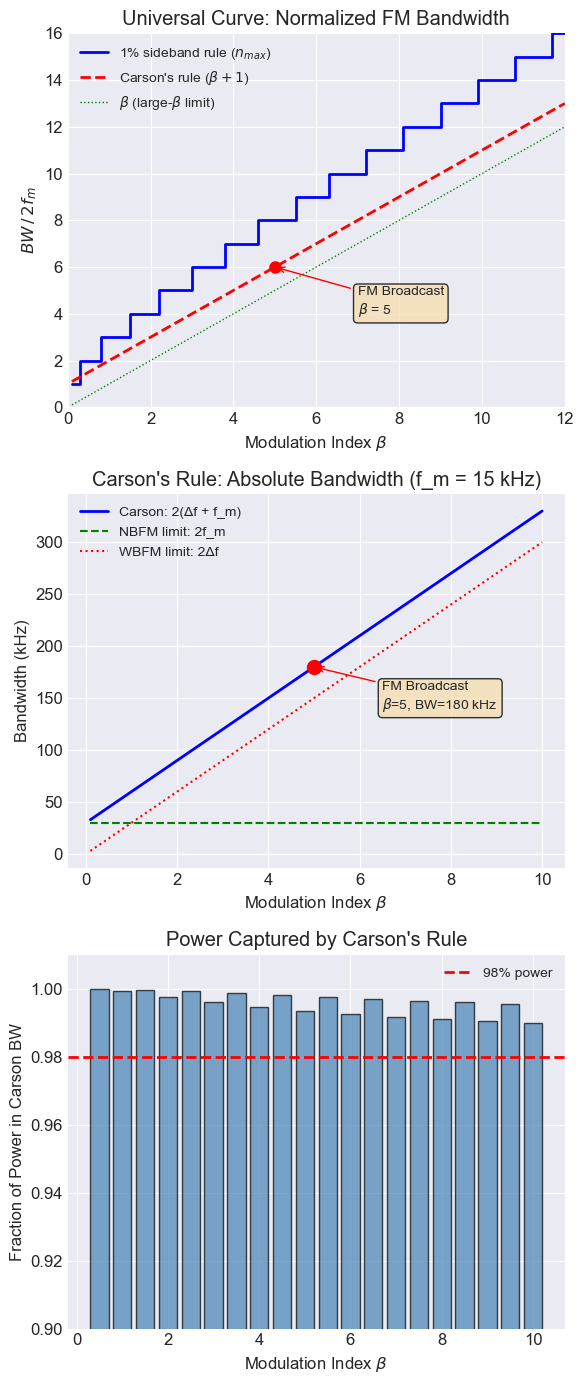

FM Bandwidth: 1% Sideband Rule vs Carson's Rule
  beta   n_max   1% BW/2fm   Carson BW/2fm    Type
--------------------------------------------------
  0.25       1           1             1.2    NBFM
  0.50       2           2             1.5    WBFM
  1.00       3           3             2.0    WBFM
  2.00       4           4             3.0    WBFM
  3.00       6           6             4.0    WBFM
  5.00       8           8             6.0    WBFM
  8.00      11          11             9.0    WBFM
 10.00      14          14            11.0    WBFM

FM Broadcast: Df = 75 kHz, W = 15 kHz, D = beta = 5
  Carson: BW = 2(75 + 15) = 180 kHz
  FCC channel: 200 kHz (includes guard bands)
  AM equivalent: BW = 2 * 15 = 30 kHz (FM uses 6x more spectrum)


In [4]:
# Part 3: FM Bandwidth Estimation - Universal Curve, Carson's Rule, Power

fm = 15e3  # 15 kHz (FM broadcast audio bandwidth)

fig, axes = plt.subplots(3, 1, figsize=(6, 14))

# --- Plot 1: Universal Curve (1% sideband rule vs Carson's rule) ---
ax = axes[0]
beta_range_uc = np.arange(0.1, 12.1, 0.1)

# 1% sideband rule: find n_max where |J_n(beta)| >= 0.01
n_max_vals = []
for beta in beta_range_uc:
    n_max = 1
    for n in range(1, 50):
        if abs(jv(n, beta)) >= 0.01:
            n_max = n
    n_max_vals.append(n_max)

# Carson's rule: normalized BW/(2fm) = beta + 1
carson_norm = beta_range_uc + 1

ax.step(beta_range_uc, n_max_vals, 'b-', linewidth=2, where='post',
        label='1% sideband rule ($n_{max}$)')
ax.plot(beta_range_uc, carson_norm, 'r--', linewidth=2,
        label="Carson's rule ($\\beta + 1$)")
ax.plot(beta_range_uc, beta_range_uc, 'g:', linewidth=1,
        label='$\\beta$ (large-$\\beta$ limit)')

# Mark FM broadcast
beta_fm = 5.0
ax.plot(beta_fm, beta_fm + 1, 'ro', markersize=8)
ax.annotate(f'FM Broadcast\n$\\beta$ = {beta_fm:.0f}',
            xy=(beta_fm, beta_fm + 1), xytext=(beta_fm + 2, beta_fm - 1),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Modulation Index $\\beta$')
ax.set_ylabel('$BW\\, /\\, 2f_m$')
ax.set_title('Universal Curve: Normalized FM Bandwidth')
ax.legend(fontsize=10)
ax.set_xlim(0, 12)
ax.set_ylim(0, 16)

# --- Plot 2: Carson's rule BW in kHz for FM broadcast ---
ax = axes[1]
beta_range = np.linspace(0.1, 10, 200)
bw_carson = 2 * (beta_range + 1) * fm / 1e3
bw_2fm = 2 * fm / 1e3 * np.ones_like(beta_range)
bw_2deltaf = 2 * beta_range * fm / 1e3

ax.plot(beta_range, bw_carson, 'b-', linewidth=2, label="Carson: 2(\u0394f + f_m)")
ax.plot(beta_range, bw_2fm, 'g--', linewidth=1.5, label='NBFM limit: 2f_m')
ax.plot(beta_range, bw_2deltaf, 'r:', linewidth=1.5, label='WBFM limit: 2\u0394f')

bw_fm = 2 * (75 + 15)
ax.plot(5.0, bw_fm, 'ro', markersize=10)
ax.annotate(f'FM Broadcast\n$\\beta$=5, BW={bw_fm} kHz',
            xy=(5.0, bw_fm), xytext=(6.5, bw_fm - 40),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Modulation Index $\\beta$')
ax.set_ylabel('Bandwidth (kHz)')
ax.set_title("Carson's Rule: Absolute Bandwidth (f_m = 15 kHz)")
ax.legend(fontsize=10)

# --- Plot 3: Power contained within Carson's BW ---
ax = axes[2]
betas = np.arange(0.5, 10.5, 0.5)
power_fraction = []

for beta in betas:
    n_carson = int(np.ceil(beta + 1))
    total_power = jv(0, beta)**2 + 2 * sum(jv(n, beta)**2 for n in range(1, 50))
    carson_power = jv(0, beta)**2 + 2 * sum(jv(n, beta)**2 for n in range(1, n_carson + 1))
    power_fraction.append(carson_power / total_power)

ax.bar(betas, power_fraction, width=0.4, color='steelblue', alpha=0.7, edgecolor='black')
ax.axhline(y=0.98, color='r', linestyle='--', label='98% power')
ax.set_xlabel('Modulation Index $\\beta$')
ax.set_ylabel('Fraction of Power in Carson BW')
ax.set_title("Power Captured by Carson's Rule")
ax.set_ylim(0.9, 1.01)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print comparison table
print("=" * 70)
print("FM Bandwidth: 1% Sideband Rule vs Carson's Rule")
print("=" * 70)
print(f"{'beta':>6}  {'n_max':>6}  {'1% BW/2fm':>10}  {'Carson BW/2fm':>14}  {'Type':>6}")
print("-" * 50)
for beta in [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0]:
    n_max = 1
    for n in range(1, 50):
        if abs(jv(n, beta)) >= 0.01:
            n_max = n
    carson = beta + 1
    typ = 'NBFM' if beta < 0.3 else 'WBFM'
    print(f"{beta:>6.2f}  {n_max:>6}  {n_max:>10}  {carson:>14.1f}  {typ:>6}")

print(f"\nFM Broadcast: Df = 75 kHz, W = 15 kHz, D = beta = 5")
print(f"  Carson: BW = 2(75 + 15) = 180 kHz")
print(f"  FCC channel: 200 kHz (includes guard bands)")
print(f"  AM equivalent: BW = 2 * 15 = 30 kHz (FM uses 6x more spectrum)")

## Part 4: Binary Frequency Shift Keying (FSK)

**FSK** is the digital counterpart to analog FM. Instead of a continuous message $m(t)$ varying the carrier frequency, FSK switches between two discrete frequencies to represent binary data:

- Bit "1" (mark): $f_1 = f_c + \Delta f$
- Bit "0" (space): $f_0 = f_c - \Delta f$
- Frequency separation: $f_1 - f_0 = 2\Delta f$

where $\Delta f$ is the **frequency deviation** from the center frequency $f_c$.

**Modulation index:** $h = \dfrac{2\Delta f}{R_b}$ — analogous to $\beta = \Delta f / f_m$ in analog FM. The modulation index controls how far the tones are spaced relative to the data rate.

The code below generates a **CPFSK** (Continuous-Phase FSK) waveform, where the phase is accumulated continuously across bit boundaries to avoid discontinuities. The distinction between discontinuous FSK and CPFSK is discussed after the plot.

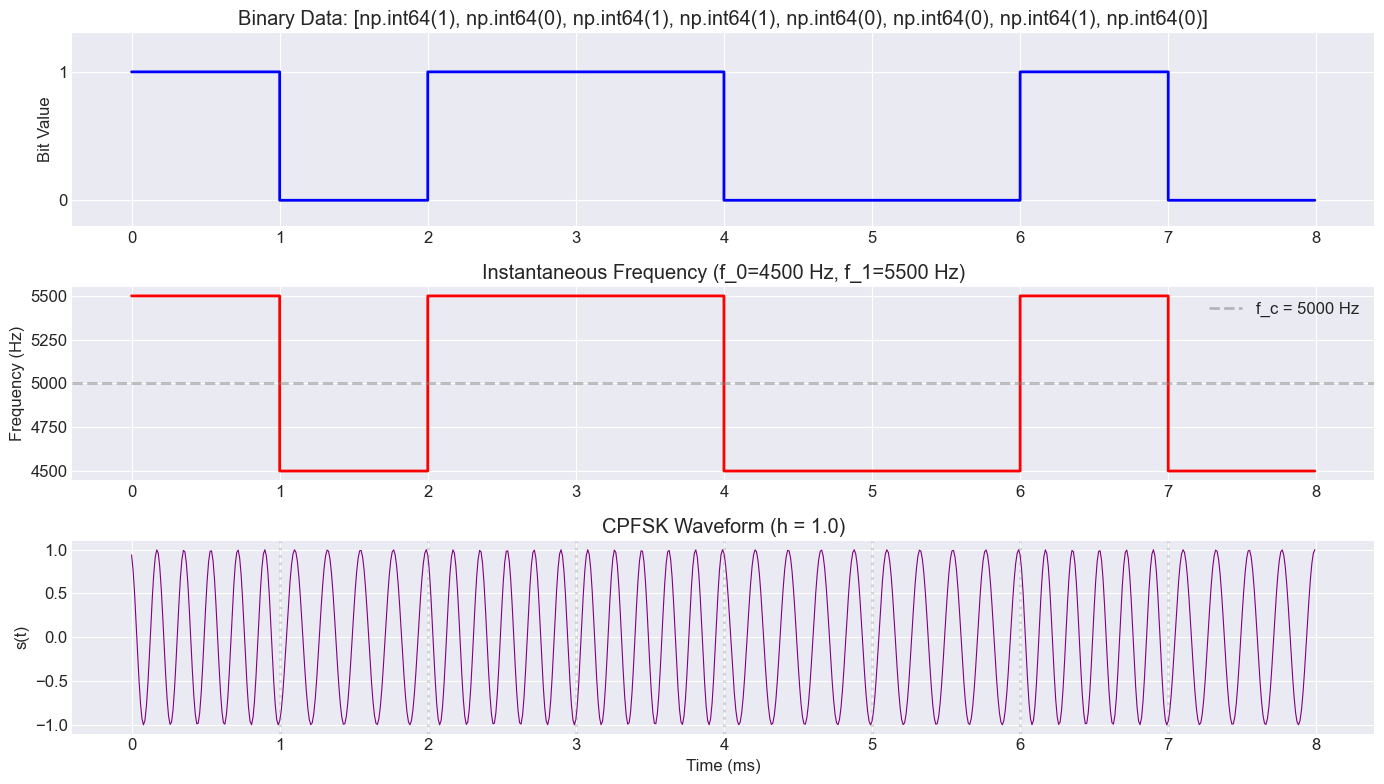

FSK Parameters
Bit rate: Rb = 1000 bps
Carrier: fc = 5000 Hz
Deviation: Delta_f = 500 Hz
f_0 (bit 0) = 4500 Hz, f_1 (bit 1) = 5500 Hz
Modulation index: h = 2*Delta_f/Rb = 1.0
FSK bandwidth (Carson): BW = 2(Delta_f + Rb) = 3000 Hz


In [5]:
# Part 4: CPFSK Signal Generation

# Parameters
Rb = 1000     # Bit rate (bps)
Tb = 1 / Rb   # Bit period (s)
fc = 5000     # Carrier frequency (Hz)
delta_f = 500 # Frequency deviation (Hz)
fs = 100000   # Sampling rate

f1 = fc + delta_f  # Frequency for bit '1'
f0 = fc - delta_f  # Frequency for bit '0'
h = 2 * delta_f / Rb  # Modulation index

# Data sequence
bits = np.array([1, 0, 1, 1, 0, 0, 1, 0])
N_bits = len(bits)

# Generate CPFSK signal (phase continuous)
samples_per_bit = int(Tb * fs)
t_total = np.arange(N_bits * samples_per_bit) / fs

# Frequency signal
freq_signal = np.zeros(len(t_total))
for i, bit in enumerate(bits):
    start = i * samples_per_bit
    end = (i + 1) * samples_per_bit
    freq_signal[start:end] = f1 if bit == 1 else f0

# CPFSK: Integrate frequency to get phase
phase = 2 * np.pi * np.cumsum(freq_signal) / fs
s_fsk = np.cos(phase)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Binary data
bit_signal = np.repeat(bits, samples_per_bit)
axes[0].step(t_total * 1000, bit_signal, 'b-', linewidth=2, where='post')
axes[0].set_ylabel('Bit Value')
axes[0].set_title(f'Binary Data: {list(bits)}')
axes[0].set_yticks([0, 1])
axes[0].set_ylim(-0.2, 1.3)

# Instantaneous frequency
axes[1].step(t_total * 1000, freq_signal, 'r-', linewidth=2, where='post')
axes[1].axhline(y=fc, color='gray', linestyle='--', alpha=0.5, label=f'f_c = {fc} Hz')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title(f'Instantaneous Frequency (f_0={f0} Hz, f_1={f1} Hz)')
axes[1].legend()

# FSK waveform
axes[2].plot(t_total * 1000, s_fsk, 'purple', linewidth=0.8)
# Add bit boundaries
for i in range(1, N_bits):
    axes[2].axvline(x=i * Tb * 1000, color='gray', linestyle=':', alpha=0.3)
axes[2].set_ylabel('s(t)')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title(f'CPFSK Waveform (h = {h:.1f})')

plt.tight_layout()
plt.show()

print("=" * 55)
print("FSK Parameters")
print("=" * 55)
print(f"Bit rate: Rb = {Rb} bps")
print(f"Carrier: fc = {fc} Hz")
print(f"Deviation: Delta_f = {delta_f} Hz")
print(f"f_0 (bit 0) = {f0} Hz, f_1 (bit 1) = {f1} Hz")
print(f"Modulation index: h = 2*Delta_f/Rb = {h:.1f}")
print(f"FSK bandwidth (Carson): BW = 2(Delta_f + Rb) = {2*(delta_f + Rb)} Hz")

### Carson's Rule for FSK

Recall Carson's rule for analog FM with a sinusoidal message at frequency $f_m$:

$$BW_\text{FM} = 2(\Delta f + f_m)$$

For FSK, the "message" is a binary waveform switching between $\pm 1$. A random NRZ (non-return-to-zero — the signal holds its value for the entire bit period rather than returning to zero between bits) bit stream has most of its energy concentrated below $R_b$ (its first spectral null is at $R_b$), so we substitute $f_m \to R_b$:

$$\boxed{BW_\text{FSK} \approx 2(\Delta f + R_b)}$$

where $\Delta f$ is the **deviation from the center frequency** (i.e., half the tone separation: $\Delta f = |f_1 - f_0|/2$).

Since $\Delta f = h R_b / 2$, we can rewrite this in terms of the modulation index $h$:

$$BW_\text{FSK} = 2\!\left(\frac{h R_b}{2} + R_b\right) = (h + 2)\, R_b$$

**Examples at $R_b = 1200$ bps:**

| Modulation index $h$ | $\Delta f$ | $BW = (h+2)R_b$ | Notes |
|:---:|:---:|:---:|:---|
| 0.5 (MSK) | 300 Hz | 3.0 kHz | Minimum orthogonal spacing |
| 1.0 | 600 Hz | 3.6 kHz | Orthogonal, wider lobes |
| 2.0 | 1200 Hz | 4.8 kHz | Wider still |

**Convention note:** Some references define $\Delta f$ as the full tone separation $|f_1 - f_0|$ rather than the deviation from center. With that convention, $h = \Delta f \cdot T_b$ and $BW = \Delta f + 2R_b$. The final bandwidth is the same either way — just be consistent with which $\Delta f$ you use.

**Why $R_b$ instead of $R_b/2$?** The fundamental frequency of an alternating 101010... pattern is $R_b/2$, but random data has significant spectral content up to $R_b$. Using $R_b$ in Carson's rule gives a conservative estimate that captures the occupied bandwidth for typical random data. Some texts use $R_b/2$, which gives a tighter (optimistic) estimate — be aware of which convention is being used.

**Comparison with analog FM:** For analog FM broadcast, $\beta = \Delta f / f_m = 75/15 = 5$ and the bandwidth is dominated by $\Delta f$. For typical FSK systems, $h$ is small (often $\leq 1$), so the $R_b$ term dominates — FSK bandwidth is often only modestly wider than the baseband data rate.

### Why MSK? Continuous Phase and Minimum Bandwidth

Standard (discontinuous) FSK switches abruptly between $f_0$ and $f_1$ at bit boundaries. These abrupt transitions create **phase discontinuities** that spread energy into high-frequency sidelobes, wasting bandwidth and causing adjacent-channel interference.

**Continuous-Phase FSK (CPFSK)** eliminates this by constraining the phase to be continuous across bit boundaries. The frequency still switches between $f_0$ and $f_1$, but the phase accumulates smoothly — no jumps. This produces a much more compact spectrum with faster sideband roll-off.

**Minimum Shift Keying (MSK)** is the special case of CPFSK with $h = 0.5$:

$$\Delta f = \frac{R_b}{4}, \qquad f_1 - f_0 = \frac{R_b}{2}$$

Why $h = 0.5$ specifically?

1. **Minimum orthogonal spacing.** For coherent detection, the two tones must be orthogonal (zero cross-correlation over $T_b$). The minimum $\Delta f$ that achieves this is $R_b/4$, giving $h = 0.5$. Any smaller $h$ and the tones can no longer be distinguished reliably.

2. **Compact spectrum.** Smaller $h$ means less frequency deviation, which means narrower bandwidth. Since $h = 0.5$ is the minimum for orthogonality, MSK achieves the **narrowest possible bandwidth** for an orthogonal CPFSK scheme: $BW = 2.5\, R_b$.

3. **Constant envelope.** Like all FSK, the amplitude never changes — only the frequency. This allows efficient **nonlinear (Class C) power amplifiers**, which clip the signal but don't distort phase/frequency. Linear amplifiers (needed for AM, QAM) are less power-efficient.

4. **Equivalent to offset QPSK with sinusoidal pulse shaping.** MSK can be decomposed into I and Q channels with half-sinusoid pulse shapes, which gives it very smooth spectral characteristics. This mathematical equivalence is exploited in practical MSK receivers.

**Real-world use:** GSM cellular (GMSK — Gaussian-filtered MSK), satellite links, and deep-space communication all use MSK or its variants for exactly these reasons: spectral efficiency, constant envelope, and orthogonal detection.

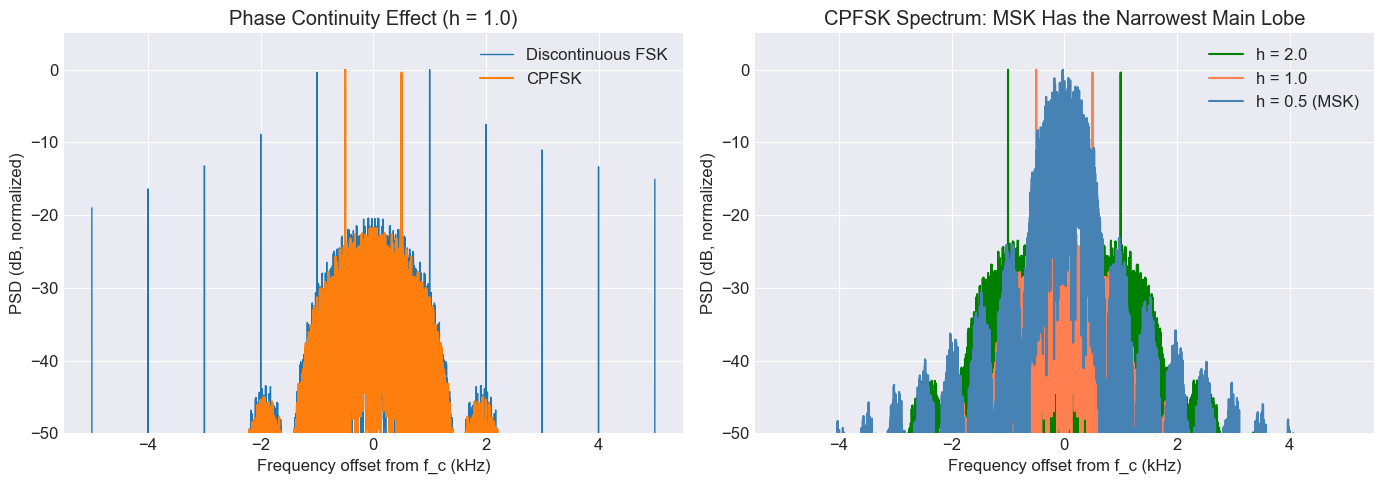

MSK Advantages Summary
1. Phase continuity -> faster sideband roll-off (left plot)
2. h = 0.5 -> narrowest spectrum for orthogonal tones (right plot)
3. Constant envelope -> compatible with nonlinear amplifiers
4. MSK BW = (0.5 + 2)*Rb = 2.5*Rb = 2500 Hz
   vs h=1 BW = 3*Rb = 3000 Hz
   vs h=2 BW = 4*Rb = 4000 Hz


In [6]:
# Discontinuous FSK vs CPFSK vs MSK: Spectral Comparison

np.random.seed(42)
N_bits_cmp = 2000
bits_cmp = np.random.randint(0, 2, N_bits_cmp)
fs_cmp = 100000
Rb_cmp = 1000
fc_cmp = 10000
samples_per_bit_cmp = int(fs_cmp / Rb_cmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Discontinuous vs Continuous Phase (h=1.0) ---
ax = axes[0]
h_demo = 1.0
delta_f_demo = h_demo * Rb_cmp / 2

for label, continuous in [('Discontinuous FSK', False), ('CPFSK', True)]:
    s = np.zeros(N_bits_cmp * samples_per_bit_cmp)
    if continuous:
        # Phase-continuous: integrate frequency
        freq_sig = np.zeros_like(s)
        for i, bit in enumerate(bits_cmp):
            idx0 = i * samples_per_bit_cmp
            idx1 = (i + 1) * samples_per_bit_cmp
            freq_sig[idx0:idx1] = fc_cmp + delta_f_demo if bit else fc_cmp - delta_f_demo
        phase = 2 * np.pi * np.cumsum(freq_sig) / fs_cmp
        s = np.cos(phase)
    else:
        # Discontinuous: independent phase per bit
        t_bit = np.arange(samples_per_bit_cmp) / fs_cmp
        for i, bit in enumerate(bits_cmp):
            freq = fc_cmp + delta_f_demo if bit else fc_cmp - delta_f_demo
            idx0 = i * samples_per_bit_cmp
            idx1 = (i + 1) * samples_per_bit_cmp
            s[idx0:idx1] = np.cos(2 * np.pi * freq * t_bit)

    N_fft = len(s)
    # Apply Hanning window to reduce spectral leakage from finite-length signal
    S = fft(s * np.hanning(N_fft)) / N_fft
    freqs = fftfreq(N_fft, 1/fs_cmp)
    mask = (freqs >= fc_cmp - 5000) & (freqs <= fc_cmp + 5000)
    psd = 20 * np.log10(np.abs(S[mask]) + 1e-12)
    psd -= np.max(psd)
    lw = 1.5 if continuous else 1.0
    ax.plot((freqs[mask] - fc_cmp) / 1000, psd, linewidth=lw, label=label)

ax.set_xlabel('Frequency offset from f_c (kHz)')
ax.set_ylabel('PSD (dB, normalized)')
ax.set_title(f'Phase Continuity Effect (h = {h_demo})')
ax.set_ylim(-50, 5)
ax.legend()

# --- Right: CPFSK at different h values ---
ax = axes[1]
h_vals = [2.0, 1.0, 0.5]
colors = ['green', 'coral', 'steelblue']
labels = ['h = 2.0', 'h = 1.0', 'h = 0.5 (MSK)']

for h_val, color, label in zip(h_vals, colors, labels):
    df = h_val * Rb_cmp / 2
    freq_sig = np.zeros(N_bits_cmp * samples_per_bit_cmp)
    for i, bit in enumerate(bits_cmp):
        idx0 = i * samples_per_bit_cmp
        idx1 = (i + 1) * samples_per_bit_cmp
        freq_sig[idx0:idx1] = fc_cmp + df if bit else fc_cmp - df
    phase = 2 * np.pi * np.cumsum(freq_sig) / fs_cmp
    s = np.cos(phase)

    N_fft = len(s)
    # Apply Hanning window to reduce spectral leakage from finite-length signal
    S = fft(s * np.hanning(N_fft)) / N_fft
    freqs = fftfreq(N_fft, 1/fs_cmp)
    mask = (freqs >= fc_cmp - 5000) & (freqs <= fc_cmp + 5000)
    psd = 20 * np.log10(np.abs(S[mask]) + 1e-12)
    psd -= np.max(psd)
    ax.plot((freqs[mask] - fc_cmp) / 1000, psd, color=color, linewidth=1.5, label=label)

ax.set_xlabel('Frequency offset from f_c (kHz)')
ax.set_ylabel('PSD (dB, normalized)')
ax.set_title('CPFSK Spectrum: MSK Has the Narrowest Main Lobe')
ax.set_ylim(-50, 5)
ax.legend()

plt.tight_layout()
plt.show()

print("=" * 60)
print("MSK Advantages Summary")
print("=" * 60)
print(f"1. Phase continuity -> faster sideband roll-off (left plot)")
print(f"2. h = 0.5 -> narrowest spectrum for orthogonal tones (right plot)")
print(f"3. Constant envelope -> compatible with nonlinear amplifiers")
print(f"4. MSK BW = (0.5 + 2)*Rb = 2.5*Rb = {2.5*Rb_cmp:.0f} Hz")
print(f"   vs h=1 BW = 3*Rb = {3*Rb_cmp:.0f} Hz")
print(f"   vs h=2 BW = 4*Rb = {4*Rb_cmp:.0f} Hz")

## Part 5: FM vs FSK Comparison

| Property | Analog FM | Binary FSK |
|----------|-----------|------------|
| Message | Continuous $m(t)$ | Binary bits |
| Frequency | $f_c + k_f m(t)$ | $f_0$ or $f_1$ |
| Mod. index | $\beta = \Delta f / f_m$ | $h = 2\Delta f / R_b$ |
| Bandwidth | $2(\Delta f + f_m)$ | $2(\Delta f + R_b)$ |
| Envelope | Constant | Constant |

**Applications:** FM broadcast, FSK in modems/IoT, MSK in GSM/satellite

## Summary

### Key Formulas

| Concept | Formula |
|---------|--------|
| FM spectrum | Carrier: $A_c J_0(\beta)$, Sidebands: $A_c J_n(\beta)$ at $f_c \pm nf_m$ |
| Carson's rule (FM) | $BW \approx 2(\Delta f + f_m) = 2(\beta + 1)f_m$ |
| Deviation ratio | $D = \Delta f / W$ (generalizes $\beta$ to non-sinusoidal messages) |
| FSK frequencies | $f_1 = f_c + \Delta f$, $f_0 = f_c - \Delta f$ |
| FSK mod. index | $h = 2\Delta f / R_b$ |
| Carson's rule (FSK) | $BW \approx 2(\Delta f + R_b) = (h + 2) R_b$ |
| MSK condition | $h = 0.5$, $\Delta f = R_b/4$, $BW = 2.5\, R_b$ |

### Key Takeaways
1. **Bessel functions** determine FM spectral components — carrier and sideband amplitudes depend on $\beta$
2. **Carson's rule** captures ~98% of FM power: $BW \approx 2(\Delta f + f_m)$
3. **FSK** is the digital version of FM — two discrete frequencies for binary data
4. **Carson's rule for FSK** substitutes $R_b$ for $f_m$: $BW \approx (h + 2) R_b$
5. **CPFSK** maintains phase continuity, giving a more compact spectrum
6. **MSK** ($h = 0.5$) provides minimum orthogonal tone spacing — used in GSM

### Next Topics
- **Lesson 12:** FSK demodulation (coherent, non-coherent, PLL)